/home/xkw/anaconda3/envs/segmentation/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 34880 (\N{CJK UNIFIED IDEOGRAPH-8840}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xkw/anaconda3/envs/segmentation/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 31649 (\N{CJK UNIFIED IDEOGRAPH-7BA1}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xkw/anaconda3/envs/segmentation/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xkw/anaconda3/envs/segmentation/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21106 (\N{CJK UNIFIED IDEOGRAPH-5272}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xkw/anaconda3/envs/segmentation/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: Us

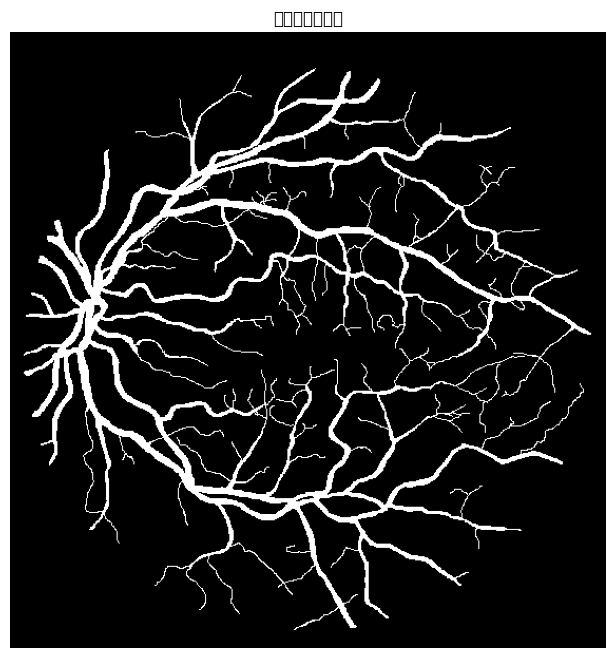

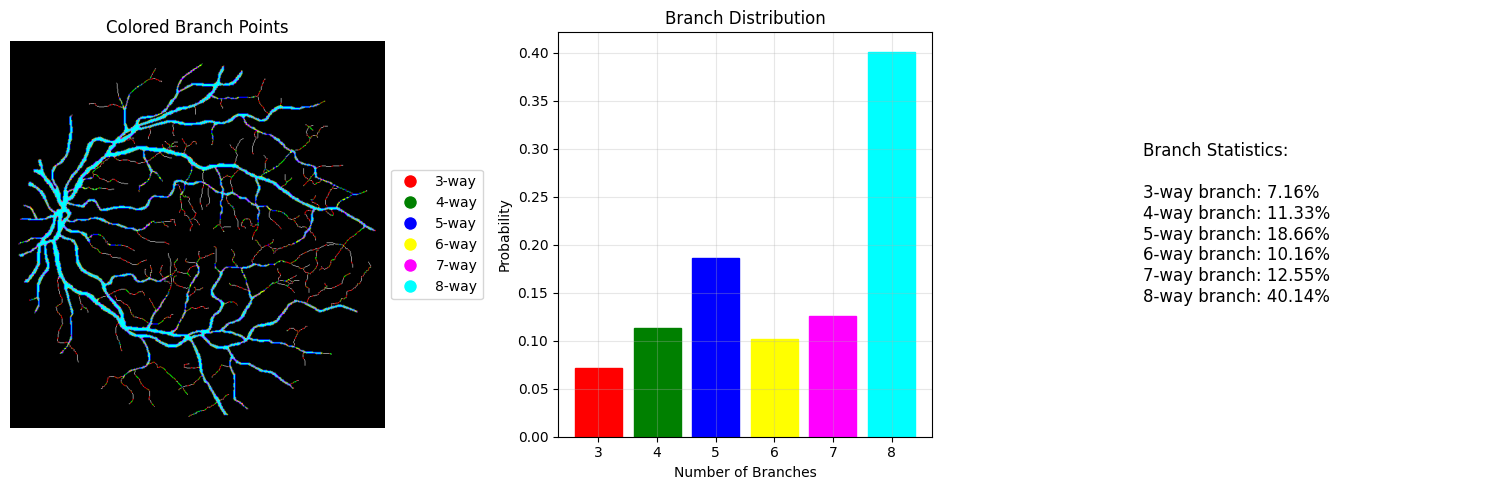


分支分布统计:
3分支: 7.16%
4分支: 11.33%
5分支: 18.66%
6分支: 10.16%
7分支: 12.55%
8分支: 40.14%


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.colors as mcolors

def detect_branch_points(vessel_image):
    """
    直接检测血管图像的分支点及其分叉数
    
    Args:
        vessel_image: 血管二值图像
    Returns:
        branch_points: 分支点位置的二值图
        branch_counts: 每个分支点的分叉数
    """
    # 确保输入是二值图像
    vessel_image = (vessel_image > 0).astype(np.uint8)
    
    # 定义8邻域模板
    kernel = np.array([[1, 1, 1],
                      [1, 0, 1],
                      [1, 1, 1]], dtype=np.uint8)
    
    # 计算每个像素的8邻域和
    neighbors = cv2.filter2D(vessel_image, -1, kernel)
    
    # 初始化分支点图和分叉数图
    branch_points = np.zeros_like(vessel_image, dtype=bool)
    branch_counts = np.zeros_like(vessel_image, dtype=np.uint8)
    
    # 获取所有血管像素点的坐标
    y_coords, x_coords = np.nonzero(vessel_image)
    
    # 对每个血管像素点进行分析
    for y, x in zip(y_coords, x_coords):
        # 提取3x3邻域
        patch = vessel_image[max(0, y-1):min(vessel_image.shape[0], y+2),
                           max(0, x-1):min(vessel_image.shape[1], x+2)]
        
        if patch.shape == (3, 3):  # 确保是完整的3x3邻域
            patch_copy = patch.copy()
            patch_copy[1, 1] = 0  # 将中心点置0
            neighbor_count = np.sum(patch_copy)
            
            # 判断是否为分支点（邻域中有3个或更多的血管像素）
            if neighbor_count >= 3:
                branch_points[y, x] = True
                branch_counts[y, x] = neighbor_count
    
    return branch_points, branch_counts

def calculate_branch_probability(vessel_image):
    """计算血管分支概率分布"""
    if len(vessel_image.shape) > 2:
        vessel_image = vessel_image[:,:,0]
    
    # 检测分支点和分叉数
    branch_points, branch_counts = detect_branch_points(vessel_image)
    
    # 统计不同分叉数的数量
    unique_counts, count_freq = np.unique(branch_counts[branch_counts > 0], return_counts=True)
    total_branches = np.sum(count_freq)
    
    # 计算各分叉数的概率分布
    branch_distribution = {
        count: freq/total_branches 
        for count, freq in zip(unique_counts, count_freq)
    }
    
    return {
        'branch_points': branch_points,
        'branch_counts': branch_counts,
        'branch_distribution': branch_distribution,
        'vessel_image': vessel_image
    }

def create_colored_branch_visualization(stats):
    """创建彩色分支点可视化图像，每种分支类型用不同颜色"""
    # 获取血管图像和分支数据
    vessel_image = stats['vessel_image']
    branch_counts = stats['branch_counts']
    
    # 创建RGB图像
    height, width = vessel_image.shape
    colored_image = np.zeros((height, width, 3), dtype=np.float32)
    
    # 定义分支类型的颜色映射
    branch_colors = {
        3: [1, 0, 0],    # 三叉分支点 - 红色
        4: [0, 1, 0],    # 四叉分支点 - 绿色
        5: [0, 0, 1],    # 五叉分支点 - 蓝色
        6: [1, 1, 0],    # 六叉分支点 - 黄色
        7: [1, 0, 1],    # 七叉分支点 - 品红
        8: [0, 1, 1],    # 八叉分支点 - 青色
    }
    
    # 首先绘制血管（细灰色）
    colored_image[vessel_image > 0] = [0.8, 0.8, 0.8]
    
    # 绘制不同类型的分支点
    for branch_type, color in branch_colors.items():
        mask = (branch_counts == branch_type)
        if np.any(mask):  # 只处理存在的分支类型
            colored_image[mask] = color
    
    return colored_image

def visualize_branch_analysis(stats):
    """综合可视化分支分析结果"""
    fig = plt.figure(figsize=(15, 5))
    
    # 1. 彩色分支点可视化
    ax1 = plt.subplot(131)
    colored_viz = create_colored_branch_visualization(stats)
    ax1.imshow(colored_viz)
    ax1.set_title('Colored Branch Points')
    
    # 添加图例
    branch_colors = {
        3: 'red',
        4: 'green',
        5: 'blue',
        6: 'yellow',
        7: 'magenta',
        8: 'cyan'
    }
    
    # 创建图例
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                markerfacecolor=color, label=f'{count}-way',
                                markersize=10)
                      for count, color in branch_colors.items()
                      if count in stats['branch_distribution']]
    ax1.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
    ax1.axis('off')
    
    # 2. 分支分布柱状图
    ax2 = plt.subplot(132)
    branch_dist = stats['branch_distribution']
    branches = sorted(list(branch_dist.keys()))
    probs = [branch_dist[b] for b in branches]
    
    bars = ax2.bar(branches, probs)
    
    # 使用相同的颜色方案
    for branch, bar in zip(branches, bars):
        if branch in branch_colors:
            bar.set_color(branch_colors[branch])
    
    ax2.set_title('Branch Distribution')
    ax2.set_xlabel('Number of Branches')
    ax2.set_ylabel('Probability')
    ax2.grid(True, alpha=0.3)
    
    # 3. 分支统计信息
    ax3 = plt.subplot(133)
    ax3.axis('off')
    info_text = "Branch Statistics:\n\n"
    for branch_num, prob in sorted(stats['branch_distribution'].items()):
        info_text += f"{branch_num}-way branch: {prob:.2%}\n"
    ax3.text(0.1, 0.5, info_text, fontsize=12, va='center')
    
    plt.tight_layout()
    return fig

# 使用示例
if __name__ == "__main__":
    # 读取图像
    ground_truth = np.array(Image.open('/home/xkw/pxlames/segmentation/gt_05.png'))
    
    # 绘制 ground_truth
    plt.figure(figsize=(8, 8))
    plt.imshow(ground_truth, cmap='gray')
    plt.title('血管分割标注图')
    plt.axis('off')
    plt.show()
    
    # 分析分支分布
    stats = calculate_branch_probability(ground_truth)
    
    # 可视化结果
    fig = visualize_branch_analysis(stats)
    plt.show()
    
    # 打印分支分布统计信息
    print("\n分支分布统计:")
    for branch_num, prob in sorted(stats['branch_distribution'].items()):
        print(f"{branch_num}分支: {prob:.2%}")

In [ ]:
# 第一步先写提取分叉点。

import numpy as np
from collections import deque

def find_branch_points(skeleton):
    height, width = skeleton.shape
    visited = np.zeros_like(skeleton)
    branch_points = []
    
    def get_neighbors(y, x):
        directions = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
        neighbors = []
        for dy, dx in directions:
            ny, nx = y + dy, x + dx
            if 0 <= ny < height and 0 <= nx < width and skeleton[ny, nx] == 1:
                neighbors.append((ny, nx))
        return neighbors
    
    def trace_branch(start_y, start_x):
        queue = deque([(start_y, start_x)])
        branch = set()
        
        while queue:
            y, x = queue.popleft()
            if visited[y, x]:
                continue
                
            visited[y, x] = 1
            branch.add((y, x))
            
            neighbors = get_neighbors(y, x)
            if len(neighbors) >= 3:
                branch_points.append((y, x))
                continue
                
            for ny, nx in neighbors:
                if not visited[ny, nx]:
                    queue.append((ny, nx))
        
        return branch
    
    # 从任意前景点开始追踪
    for y in range(height):
        for x in range(width):
            if skeleton[y, x] == 1 and not visited[y, x]:
                trace_branch(y, x)
    
    return branch_points

if __name__ == "__main__":
    # 读取图像
    ground_truth = np.array(Image.open('/home/xkw/pxlames/segmentation/gt_05.png'))
    
    # 如果是彩色图像，转换为灰度图
    if len(ground_truth.shape) > 2:
        ground_truth = ground_truth[:,:,0]
    
    # 二值化处理
    binary = (ground_truth > 0).astype(np.uint8)
    
    # 骨架化处理
    skeleton = skeletonize(binary)
    
    # 检测分支点
    branch_points = find_branch_points(skeleton)
    
    # 可视化结果
    plt.figure(figsize=(15, 5))
    
    # 显示原始图像
    plt.subplot(131)
    plt.imshow(ground_truth, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    # 显示骨架图像
    plt.subplot(132)
    plt.imshow(skeleton, cmap='gray')
    plt.title('Skeleton')
    plt.axis('off')
    
    # 显示带分支点的骨架图像
    plt.subplot(133)
    plt.imshow(skeleton, cmap='gray')
    # 标记所有分支点
    branch_points = np.array(branch_points)
    if len(branch_points) > 0:
        plt.plot(branch_points[:, 1], branch_points[:, 0], 'go', markersize=5)
    plt.title('Branch Points')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 打印分支点数量
    print(f"检测到的分支点数量: {len(branch_points)}")


# 第二步计算分叉点附近的分支数目。

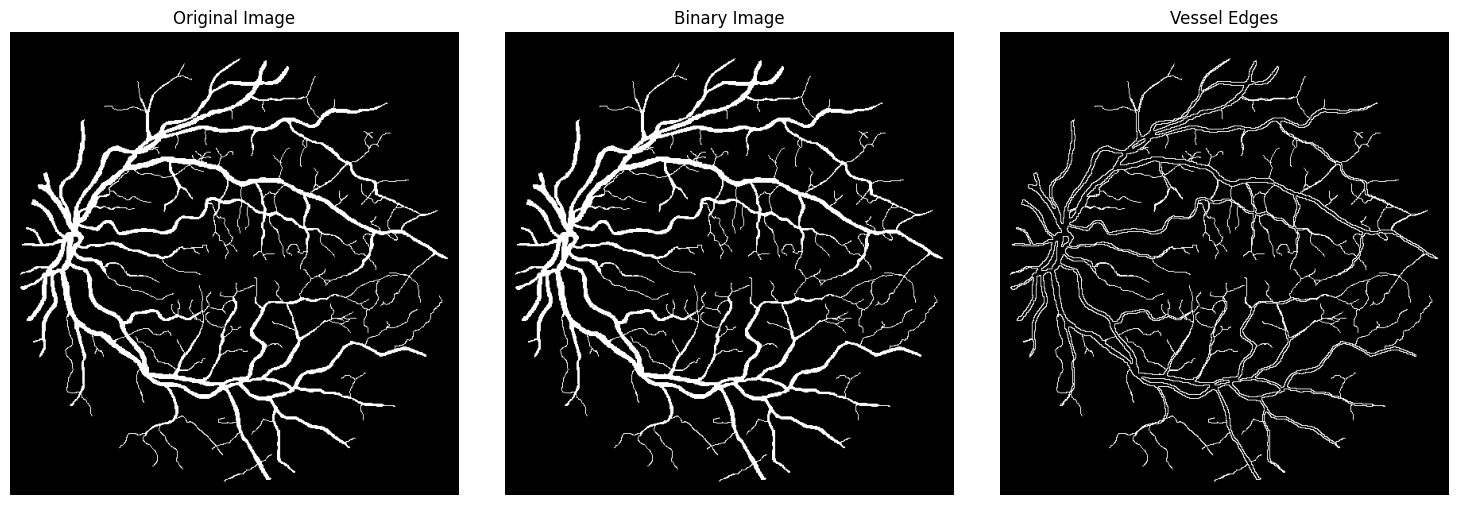

检测到的边缘像素数量: 19282


In [2]:
# 获取血管边缘的像素

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

def get_vessel_edges(binary_image):
    """
    获取血管边缘像素
    
    Args:
        binary_image: 二值图像（血管为1，背景为0）
    Returns:
        edges: 边缘像素的二值图（边缘为1，其他为0）
    """
    # 确保输入是二值图像
    binary = (binary_image > 0).astype(np.uint8)
    
    # 使用腐蚀操作
    kernel = np.ones((3,3), np.uint8)
    eroded = cv2.erode(binary, kernel, iterations=1)
    
    # 边缘是原图与腐蚀图的差
    edges = binary - eroded
    
    return edges.astype(np.uint8)

if __name__ == "__main__":
    # 读取图像
    ground_truth = np.array(Image.open('/home/xkw/pxlames/segmentation/gt_05.png'))
    
    # 如果是彩色图像，转换为灰度图
    if len(ground_truth.shape) > 2:
        ground_truth = ground_truth[:,:,0]
    
    # 二值化处理
    binary = (ground_truth > 0).astype(np.uint8)
    
    # 获取边缘
    edges = get_vessel_edges(binary)
    
    # 可视化结果
    plt.figure(figsize=(15, 5))
    
    # 显示原始图像
    plt.subplot(131)
    plt.imshow(ground_truth, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    # 显示二值图像
    plt.subplot(132)
    plt.imshow(binary, cmap='gray')
    plt.title('Binary Image')
    plt.axis('off')
    
    # 显示边缘图像
    plt.subplot(133)
    plt.imshow(edges, cmap='gray')
    plt.title('Vessel Edges')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 打印边缘像素数量
    print(f"检测到的边缘像素数量: {np.sum(edges)}")
    
    


In [8]:
def distribution_penalty(pred_dist, gt_dist):
    """
    计算预测分布与GT分布的不符合惩罚
    
    Args:
        pred_dist: 预测边缘点8邻域分布 (字典或数组)
        gt_dist: GT边缘点8邻域分布 (字典或数组)
    """
    # KL散度作为主要惩罚
    kl_div = 0
    for k in range(8):
        if gt_dist[k] > 0:
            kl_div += gt_dist[k] * np.log(gt_dist[k] / (pred_dist[k] + 1e-6))
            
    # # 额外惩罚分支点(5-7邻域)的分布差异
    # branch_penalty = np.sum(np.abs(gt_dist[5:] - pred_dist[5:])) * 2
    
    return kl_div

已处理 gt_14.png, 检测到 568 个分支点
已处理 gt_02.png, 检测到 707 个分支点
已处理 gt_17.png, 检测到 573 个分支点
已处理 gt_15.png, 检测到 428 个分支点
已处理 gt_06.png, 检测到 900 个分支点
已处理 gt_09.png, 检测到 642 个分支点
已处理 gt_08.png, 检测到 598 个分支点
已处理 gt_13.png, 检测到 790 个分支点
已处理 gt_20.png, 检测到 423 个分支点
已处理 gt_18.png, 检测到 411 个分支点
已处理 gt_03.png, 检测到 787 个分支点
已处理 gt_16.png, 检测到 580 个分支点
已处理 gt_19.png, 检测到 529 个分支点
已处理 gt_07.png, 检测到 711 个分支点
已处理 gt_05.png, 检测到 764 个分支点
已处理 gt_04.png, 检测到 666 个分支点
已处理 gt_10.png, 检测到 807 个分支点
已处理 gt_01.png, 检测到 677 个分支点
已处理 gt_11.png, 检测到 976 个分支点
已处理 gt_12.png, 检测到 658 个分支点


/tmp/ipykernel_148543/1811859738.py:107: UserWarning: Glyph 37051 (\N{CJK UNIFIED IDEOGRAPH-90BB}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_148543/1811859738.py:107: UserWarning: Glyph 22495 (\N{CJK UNIFIED IDEOGRAPH-57DF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_148543/1811859738.py:107: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_148543/1811859738.py:107: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_148543/1811859738.py:107: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_148543/1811859738.py:107: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_148543/1811859738.py:107: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from curren

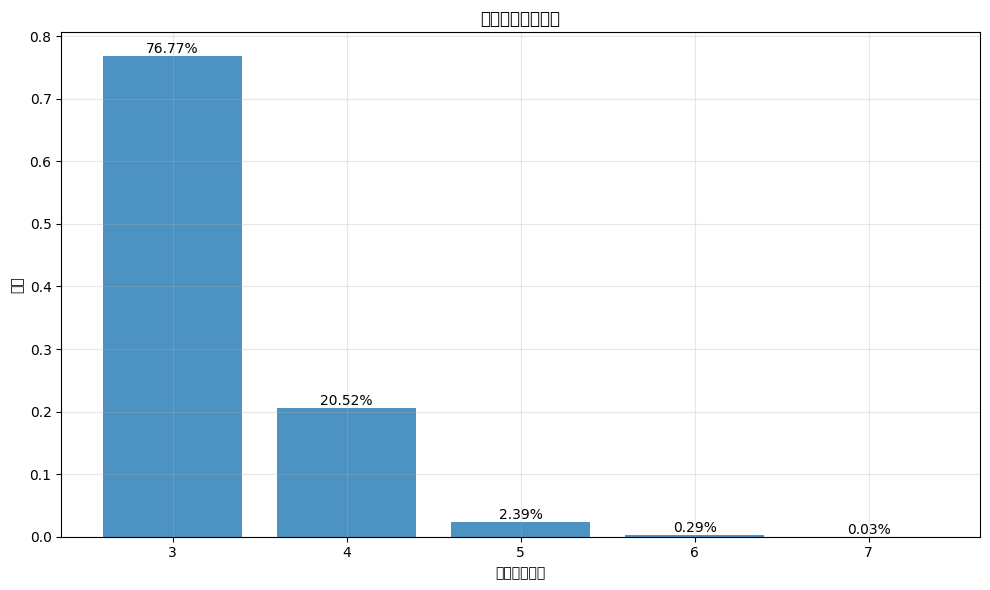


血管分支模式分布统计:
邻域像素数量 3: 76.77%
邻域像素数量 4: 20.52%
邻域像素数量 5: 2.39%
邻域像素数量 6: 0.29%
邻域像素数量 7: 0.03%


In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from skimage.morphology import skeletonize
import os

def analyze_junction_neighborhood(skeleton, junctions):
    """分析骨架图上分支点的8邻域分布"""
    skeleton_uint8 = skeleton.astype(np.uint8)
    kernel = np.array([[1, 1, 1],
                      [1, 0, 1],
                      [1, 1, 1]], dtype=np.uint8)
    
    neighbor_counts = cv2.filter2D(skeleton_uint8, -1, kernel)
    
    junction_neighbors = []
    for x, y in junctions:
        junction_neighbors.append(neighbor_counts[x, y])
    
    junction_neighbors = np.array(junction_neighbors)
    unique_counts, count_freq = np.unique(junction_neighbors, return_counts=True)
    total_junctions = np.sum(count_freq)
    
    distribution = {
        int(count): freq/total_junctions 
        for count, freq in zip(unique_counts, count_freq)
    }
    
    return distribution

def detect_junctions(skeleton):
    """检测骨架图中的分支点"""
    points = np.argwhere(skeleton)
    junctions = set()
    for point in points:
        x, y = point
        neighbors = skeleton[max(0, x-1):x+2, max(0, y-1):y+2]
        if np.sum(neighbors)-1 > 2:  # 交点判定条件，可根据需求调整
            junctions.add((x, y))
    return list(junctions)

# 主程序
if __name__ == "__main__":
    gt_dir = '/home/xkw/pxlames/segmentation/outputs/testResults/DRIVE-unet-BceDice_256_16_0.001_2000'
    
    # 存储所有图像的分支点邻域数量
    all_neighbor_counts = []
    
    # 处理所有图像
    for filename in os.listdir(gt_dir):
        if filename.endswith('.png') and 'gt' in filename:
            img_path = os.path.join(gt_dir, filename)
            
            # 读取和处理图像
            ground_truth = np.array(Image.open(img_path))
            if len(ground_truth.shape) > 2:
                ground_truth = ground_truth[:,:,0]
            
            # 二值化和骨架提取
            gt_binary = (ground_truth > 0).astype(np.uint8)
            gt_skeleton = skeletonize(gt_binary > 0)
            
            # 检测分支点
            junctions = detect_junctions(gt_skeleton)
            
            # 对每个分支点统计邻域
            skeleton_uint8 = gt_skeleton.astype(np.uint8)
            kernel = np.array([[1, 1, 1],
                             [1, 0, 1],
                             [1, 1, 1]], dtype=np.uint8)
            neighbor_counts = cv2.filter2D(skeleton_uint8, -1, kernel)
            
            for x, y in junctions:
                all_neighbor_counts.append(neighbor_counts[x, y])
            
            print(f"已处理 {filename}, 检测到 {len(junctions)} 个分支点")
    
    # 计算总体分布
    all_neighbor_counts = np.array(all_neighbor_counts)
    unique_counts, count_freq = np.unique(all_neighbor_counts, return_counts=True)
    total_points = len(all_neighbor_counts)
    
    distribution = {
        int(count): freq/total_points 
        for count, freq in zip(unique_counts, count_freq)
    }
    
    # 可视化分布
    plt.figure(figsize=(10, 6))
    counts = list(distribution.keys())
    probs = list(distribution.values())
    
    bars = plt.bar(counts, probs, alpha=0.8)
    
    # 在柱子上添加具体数值
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}',
                ha='center', va='bottom')
    
    plt.title('血管分支模式分布')
    plt.xlabel('邻域像素数量')
    plt.ylabel('概率')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 打印分布信息
    print("\n血管分支模式分布统计:")
    for count, prob in sorted(distribution.items()):
        print(f"邻域像素数量 {count}: {prob:.2%}")

# 测试一张图片，观察交点

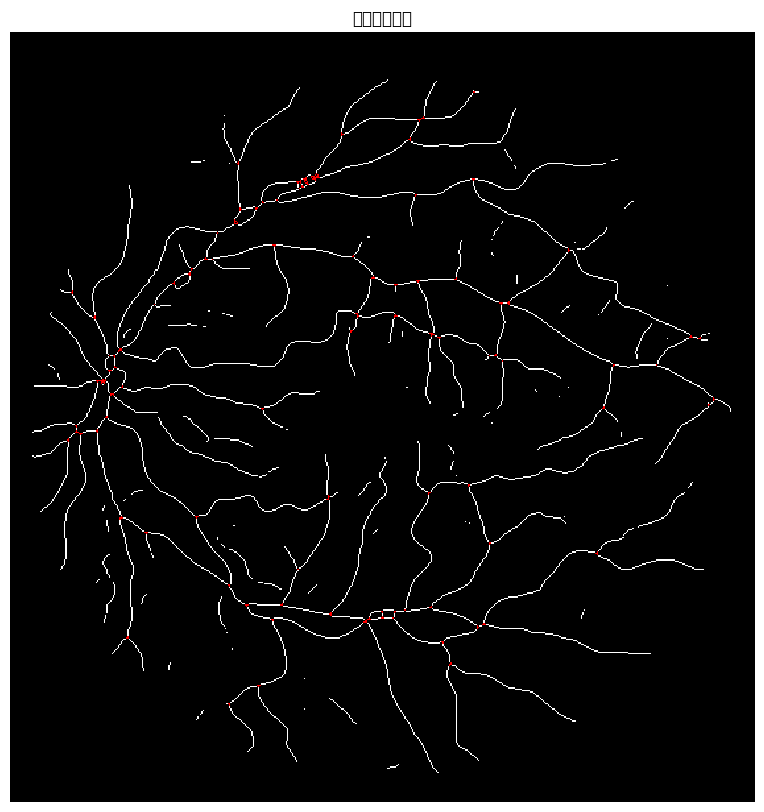

/tmp/ipykernel_118945/2913688522.py:201: UserWarning: Glyph 37051 (\N{CJK UNIFIED IDEOGRAPH-90BB}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_118945/2913688522.py:201: UserWarning: Glyph 22495 (\N{CJK UNIFIED IDEOGRAPH-57DF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_118945/2913688522.py:201: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_118945/2913688522.py:201: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_118945/2913688522.py:201: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_118945/2913688522.py:201: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_118945/2913688522.py:201: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from curren

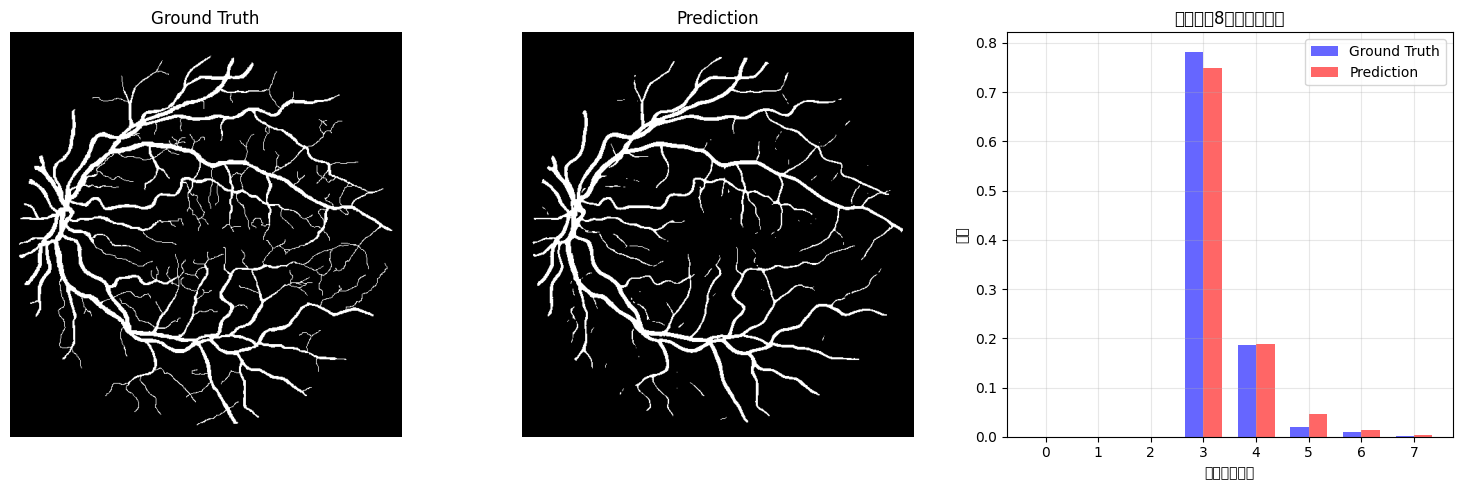


Ground Truth边缘像素8邻域分布统计:
邻域像素数量 3: 78.24%
邻域像素数量 4: 18.70%
邻域像素数量 5: 2.04%
邻域像素数量 6: 0.89%
邻域像素数量 7: 0.13%

Prediction边缘像素8邻域分布统计:
邻域像素数量 3: 74.86%
邻域像素数量 4: 18.85%
邻域像素数量 5: 4.64%
邻域像素数量 6: 1.37%
邻域像素数量 7: 0.27%

分布惩罚值: 0.0115


In [41]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.colors as mcolors

def distribution_penalty(pred_dist, gt_dist):
    """
    计算预测分布与GT分布的不符合惩罚
    
    Args:
        pred_dist: 预测边缘点8邻域分布 (字典或数组)
        gt_dist: GT边缘点8邻域分布 (字典或数组)
    """
    # KL散度作为主要惩罚
    kl_div = 0
    for k in range(8):
        if gt_dist[k] > 0:
            kl_div += gt_dist[k] * np.log(gt_dist[k] / (pred_dist[k] + 1e-6))
            
    # # 额外惩罚分支点(5-7邻域)的分布差异
    # branch_penalty = np.sum(np.abs(gt_dist[5:] - pred_dist[5:])) * 2
    
    return kl_div

def analyze_junction_neighborhood(skeleton, junctions):
    """
    分析骨架图上交叉点的8邻域分布
    
    Args:
        skeleton: 血管骨架图 (二值图，值为True/False或1/0)
        junctions: 交叉点坐标列表 [(x1,y1), (x2,y2),...]
    Returns:
        distribution: 8邻域像素数量的概率分布字典
    """
    # 将骨架图转换为uint8类型，以便进行卷积运算
    skeleton_uint8 = skeleton.astype(np.uint8)
    
    # 定义8邻域核
    kernel = np.array([[1, 1, 1],
                      [1, 0, 1],
                      [1, 1, 1]], dtype=np.uint8)
    
    # 计算每个像素的8邻域和
    neighbor_counts = cv2.filter2D(skeleton_uint8, -1, kernel)
    
    # 只统计交叉点处的邻域
    junction_neighbors = []
    for x, y in junctions:
        junction_neighbors.append(neighbor_counts[x, y])
    
    # 将列表转换为numpy数组便于统计
    junction_neighbors = np.array(junction_neighbors)
    
    # 计算概率分布
    unique_counts, count_freq = np.unique(junction_neighbors, return_counts=True)
    total_junctions = np.sum(count_freq)
    
    distribution = {
        int(count): freq/total_junctions 
        for count, freq in zip(unique_counts, count_freq)
    }
    
    return distribution


def visualize_edge_distribution(distribution):
    """
    可视化边缘像素的8邻域分布
    
    Args:
        distribution: 8邻域像素数量的概率分布字典
    """
    plt.figure(figsize=(10, 6))
    
    # 绘制柱状图
    counts = list(distribution.keys())
    probs = list(distribution.values())
    
    bars = plt.bar(counts, probs)
    
    # 在柱子上添加具体数值
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}',
                ha='center', va='bottom')
    
    plt.title('血管边缘像素8邻域分布')
    plt.xlabel('邻域像素数量')
    plt.ylabel('概率')
    plt.grid(True, alpha=0.3)
    
    return plt.gcf()

def highlight_junctions_on_skeleton(skeleton, junctions):
    """
    在骨架图上用红色标记交叉点位置
    
    Args:
        skeleton: 骨架图（布尔数组或二值图像）
        junctions: 交叉点坐标列表 [(x, y), ...]
    
    Returns:
        highlighted_skeleton: 标记了红色交叉点的RGB图像
    """
    # 创建3通道RGB图像
    highlighted_skeleton = np.zeros((*skeleton.shape, 3), dtype=np.uint8)
    
    # 将骨架设为白色 (255, 255, 255)
    highlighted_skeleton[skeleton > 0] = [255, 255, 255]
    
    # 在骨架图上标记交叉点为红色 (255, 0, 0)
    for x, y in junctions:
        # 检查坐标是否在图像范围内
        if 0 <= x < skeleton.shape[0] and 0 <= y < skeleton.shape[1]:
            # 确认该点确实是骨架上的点
            if skeleton[x, y]:
                highlighted_skeleton[x, y] = [255, 0, 0]  # 红色
    
    return highlighted_skeleton

# 使用示例
if __name__ == "__main__":
    # 读取图像
    ground_truth = np.array(Image.open('/home/xkw/pxlames/segmentation/gt_05.png'))
    prediction = np.load('/home/xkw/pxlames/segmentation/pred_05.npy')
    
    # 预处理ground truth
    if len(ground_truth.shape) > 2:
        ground_truth = ground_truth[:,:,0]
    gt_binary = (ground_truth > 0).astype(np.uint8)
    
    # 预处理prediction
    pred_binary = (prediction > 0.5).astype(np.uint8)
    # # 获取边缘
    # gt_edges = get_vessel_edges(gt_binary)
    # pred_edges = get_vessel_edges(pred_binary)
    gt_skeleton = skeletonize(gt_binary > 0)  # 直接使用布尔值
    pred_skeleton = skeletonize(pred_binary > 0)

    # 改进的交点检测，标记交点而不是删除
    def detect_junctions(skeleton):
        points = np.argwhere(skeleton)
        junctions = set()
        for point in points:
            x, y = point
            neighbors = skeleton[max(0, x-1):x+2, max(0, y-1):y+2]
            if np.sum(neighbors)-1 > 2:  # 交点判定条件，可根据需求调整
                junctions.add((x, y))
        return list(junctions)
    
    gt_skeleton_junction = detect_junctions(gt_skeleton)
    pred_skeleton_junction = detect_junctions(pred_skeleton)
    
    # 在图像上标记交点
    highlighted_image = highlight_junctions_on_skeleton(pred_skeleton, pred_skeleton_junction)

    # 显示结果
    plt.figure(figsize=(10, 10))
    plt.imshow(highlighted_image,interpolation='None')
    plt.axis('off')
    plt.title('交点标记结果')
    plt.show()
    
    # 分析交叉点邻域分布
    gt_dist = analyze_junction_neighborhood(gt_skeleton, gt_skeleton_junction)
    pred_dist = analyze_junction_neighborhood(pred_skeleton, pred_skeleton_junction)
    
    # 可视化对比
    plt.figure(figsize=(15, 5))
    
    # 1. 显示原始图像和预测结果
    plt.subplot(131)
    plt.imshow(gt_binary, cmap='gray')
    plt.title('Ground Truth')
    plt.axis('off')
    
    plt.subplot(132)
    plt.imshow(pred_binary, cmap='gray')
    plt.title('Prediction')
    plt.axis('off')
    
    # 2. 显示分布对比
    plt.subplot(133)
    x = range(max(max(gt_dist.keys()), max(pred_dist.keys())) + 1)
    width = 0.35
    
    gt_probs = [gt_dist.get(i, 0) for i in x]
    pred_probs = [pred_dist.get(i, 0) for i in x]
    
    plt.bar(np.array(x) - width/2, gt_probs, width, label='Ground Truth', color='blue', alpha=0.6)
    plt.bar(np.array(x) + width/2, pred_probs, width, label='Prediction', color='red', alpha=0.6)
    
    plt.title('边缘像素8邻域分布对比')
    plt.xlabel('邻域像素数量')
    plt.ylabel('概率')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 打印分布信息
    print("\nGround Truth边缘像素8邻域分布统计:")
    for count, prob in sorted(gt_dist.items()):
        print(f"邻域像素数量 {count}: {prob:.2%}")
        
    print("\nPrediction边缘像素8邻域分布统计:")
    for count, prob in sorted(pred_dist.items()):
        print(f"邻域像素数量 {count}: {prob:.2%}")
    
    # 计算分布惩罚
    # 将字典转换为数组形式
    max_neighbors = max(max(gt_dist.keys()), max(pred_dist.keys()))
    gt_array = np.array([gt_dist.get(i, 0) for i in range(max_neighbors + 1)])
    pred_array = np.array([pred_dist.get(i, 0) for i in range(max_neighbors + 1)])
    
    penalty = distribution_penalty(pred_array, gt_array)
    print(f"\n分布惩罚值: {penalty:.4f}")

/tmp/ipykernel_148543/4073654906.py:95: UserWarning: Glyph 37051 (\N{CJK UNIFIED IDEOGRAPH-90BB}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_148543/4073654906.py:95: UserWarning: Glyph 22495 (\N{CJK UNIFIED IDEOGRAPH-57DF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_148543/4073654906.py:95: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_148543/4073654906.py:95: UserWarning: Glyph 32032 (\N{CJK UNIFIED IDEOGRAPH-7D20}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_148543/4073654906.py:95: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_148543/4073654906.py:95: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_148543/4073654906.py:95: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from current font.

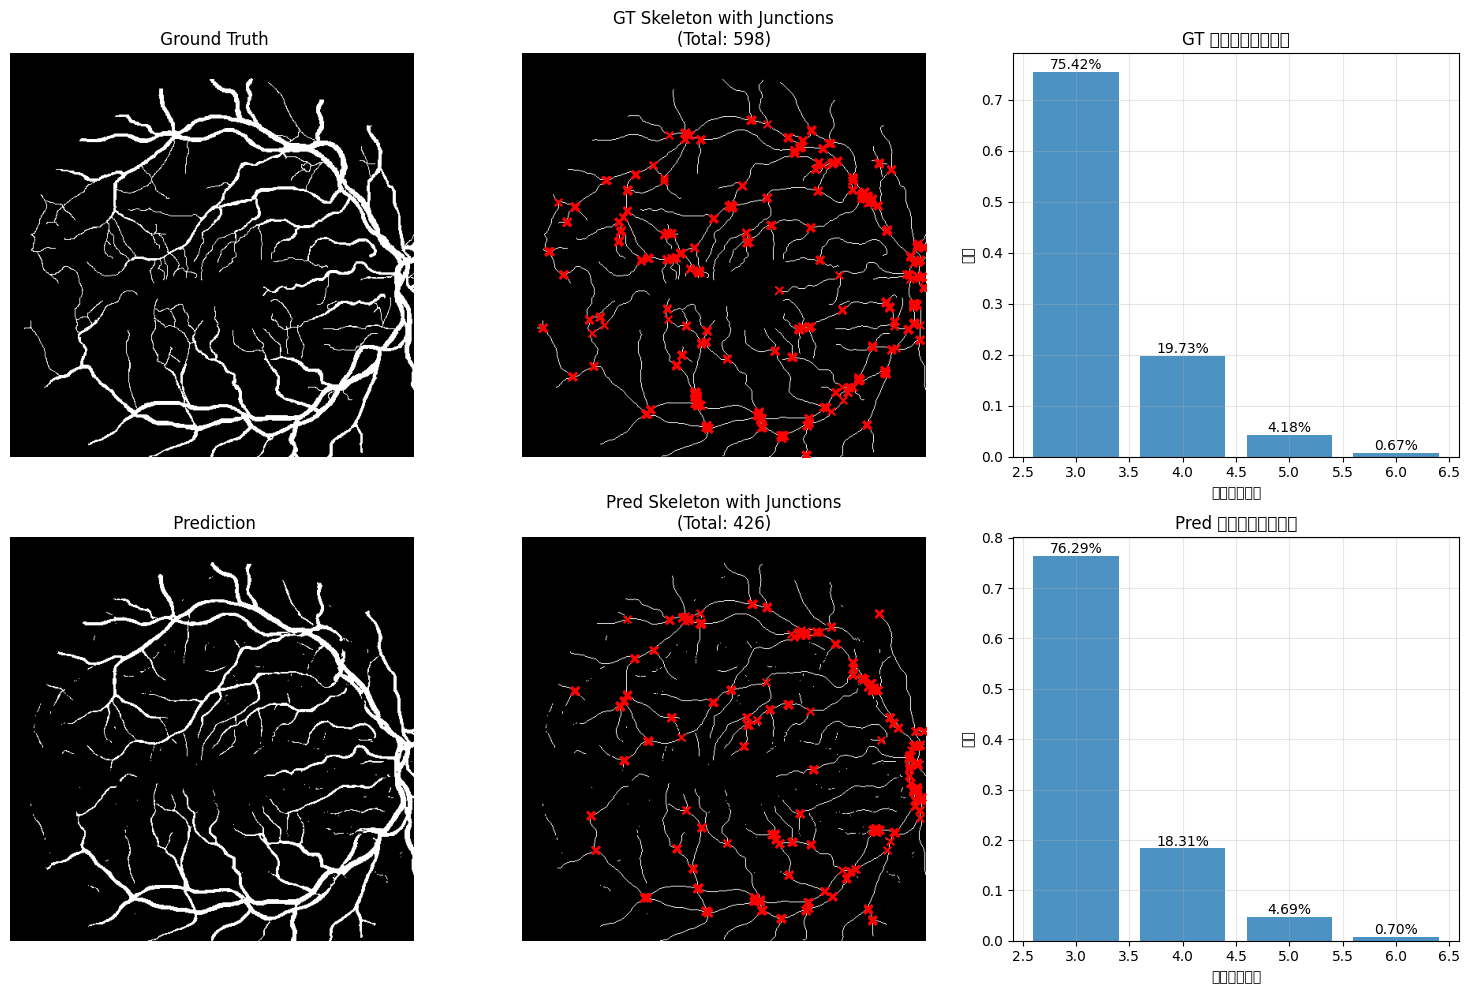


Ground Truth 血管分支模式分布统计:
邻域像素数量 3: 75.42%
邻域像素数量 4: 19.73%
邻域像素数量 5: 4.18%
邻域像素数量 6: 0.67%
总计检测到 598 个分支点

Prediction 血管分支模式分布统计:
邻域像素数量 3: 76.29%
邻域像素数量 4: 18.31%
邻域像素数量 5: 4.69%
邻域像素数量 6: 0.70%
总计检测到 426 个分支点


In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from skimage.morphology import skeletonize

def analyze_junction_neighborhood(skeleton, junctions):
    """分析骨架图上分支点的8邻域分布"""
    skeleton_uint8 = skeleton.astype(np.uint8)
    kernel = np.array([[1, 1, 1],
                      [1, 0, 1],
                      [1, 1, 1]], dtype=np.uint8)
    
    neighbor_counts = cv2.filter2D(skeleton_uint8, -1, kernel)
    
    junction_neighbors = []
    for x, y in junctions:
        junction_neighbors.append(neighbor_counts[x, y])
    
    junction_neighbors = np.array(junction_neighbors)
    unique_counts, count_freq = np.unique(junction_neighbors, return_counts=True)
    total_junctions = np.sum(count_freq)
    
    distribution = {
        int(count): freq/total_junctions 
        for count, freq in zip(unique_counts, count_freq)
    }
    
    return distribution

def detect_junctions(skeleton):
    """检测骨架图中的分支点"""
    points = np.argwhere(skeleton)
    junctions = set()
    for point in points:
        x, y = point
        neighbors = skeleton[max(0, x-1):x+2, max(0, y-1):y+2]
        if np.sum(neighbors)-1 > 2:  # 交点判定条件，可根据需求调整
            junctions.add((x, y))
    return list(junctions)

def process_image(image, title):
    """处理单张图像并返回结果"""
    # 二值化和骨架提取
    binary = (image > 0).astype(np.uint8)
    skeleton = skeletonize(binary > 0)
    
    # 检测分支点
    junctions = detect_junctions(skeleton)
    
    # 计算分布
    distribution = analyze_junction_neighborhood(skeleton, junctions)
    
    return binary, skeleton, junctions, distribution

def plot_results(gt_results, pred_results, title_prefix=""):
    """可视化结果对比"""
    gt_binary, gt_skeleton, gt_junctions, gt_dist = gt_results
    pred_binary, pred_skeleton, pred_junctions, pred_dist = pred_results
    
    plt.figure(figsize=(15, 10))
    
    # Ground Truth 结果
    plt.subplot(231)
    plt.imshow(gt_binary, cmap='gray')
    plt.title(f'{title_prefix} Ground Truth')
    plt.axis('off')
    
    plt.subplot(232)
    plt.imshow(gt_skeleton, cmap='gray')
    junction_y, junction_x = zip(*gt_junctions)
    plt.scatter(junction_x, junction_y, c='red', s=30, marker='x')
    plt.title(f'GT Skeleton with Junctions\n(Total: {len(gt_junctions)})')
    plt.axis('off')
    
    plt.subplot(233)
    plot_distribution(gt_dist, "GT 血管分支模式分布")
    
    # Prediction 结果
    plt.subplot(234)
    plt.imshow(pred_binary, cmap='gray')
    plt.title(f'{title_prefix} Prediction')
    plt.axis('off')
    
    plt.subplot(235)
    plt.imshow(pred_skeleton, cmap='gray')
    junction_y, junction_x = zip(*pred_junctions)
    plt.scatter(junction_x, junction_y, c='red', s=30, marker='x')
    plt.title(f'Pred Skeleton with Junctions\n(Total: {len(pred_junctions)})')
    plt.axis('off')
    
    plt.subplot(236)
    plot_distribution(pred_dist, "Pred 血管分支模式分布")
    
    plt.tight_layout()
    plt.show()

def plot_distribution(distribution, title):
    """绘制分布图"""
    counts = list(distribution.keys())
    probs = list(distribution.values())
    
    bars = plt.bar(counts, probs, alpha=0.8)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}',
                ha='center', va='bottom')
    
    plt.title(title)
    plt.xlabel('邻域像素数量')
    plt.ylabel('概率')
    plt.grid(True, alpha=0.3)

def print_statistics(distribution, total_points, prefix=""):
    """打印统计信息"""
    print(f"\n{prefix}血管分支模式分布统计:")
    for count, prob in sorted(distribution.items()):
        print(f"邻域像素数量 {count}: {prob:.2%}")
    print(f"总计检测到 {total_points} 个分支点")

# 主程序
if __name__ == "__main__":
    # 读取图像
    gt_path = '/home/xkw/pxlames/segmentation/outputs/testResults/DRIVE-unet-BceDice_256_16_0.001_2000/gt_08.png'
    pred_path = '/home/xkw/pxlames/segmentation/outputs/testResults/DRIVE-unet-BceDice_256_16_0.001_2000/pred_08.png'
    
    # 读取和处理图像
    ground_truth = np.array(Image.open(gt_path))
    prediction = np.array(Image.open(pred_path))
    
    if len(ground_truth.shape) > 2:
        ground_truth = ground_truth[:,:,0]
    if len(prediction.shape) > 2:
        prediction = prediction[:,:,0]
    
    # 处理两张图像
    gt_results = process_image(ground_truth, "Ground Truth")
    pred_results = process_image(prediction, "Prediction")
    
    # 可视化结果
    plot_results(gt_results, pred_results)
    
    # 打印统计信息
    gt_dist = gt_results[3]
    pred_dist = pred_results[3]
    gt_junctions = gt_results[2]
    pred_junctions = pred_results[2]
    
    print_statistics(gt_dist, len(gt_junctions), "Ground Truth ")
    print_statistics(pred_dist, len(pred_junctions), "Prediction ")